# Cell 1: Tai dataset Cat and Dog tu Kaggle

In [5]:
!pip install -q kaggle

In [6]:
import kagglehub, os

# Download dataset (lan dau chay se mat vai phut de tai ve)
path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Path to dataset files:", path)

# In cau truc thu muc de biet anh thuc su nam o dau
print("\n--- Cau truc thu muc (chi hien thu muc co anh) ---")
for root, dirs, fs in os.walk(path):
    n_img = len([f for f in fs if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    if n_img > 0:
        print(root, "->", n_img, "anh")

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog

--- Cau truc thu muc (chi hien thu muc co anh) ---
/kaggle/input/cat-and-dog/test_set/test_set/dogs -> 1012 anh
/kaggle/input/cat-and-dog/test_set/test_set/cats -> 1011 anh
/kaggle/input/cat-and-dog/training_set/training_set/dogs -> 4005 anh
/kaggle/input/cat-and-dog/training_set/training_set/cats -> 4000 anh


# Cell 2: Nap thu vien

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tensorflow.keras.utils import load_img, img_to_array, to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense
import random

# Cell 3: Doc toan bo anh thanh mang numpy

In [8]:
# Cell 3 (sua): gan nhan dua tren TEN FILE, khong dung ca duong dan
import os
from glob import glob
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

IMG_SIZE = (64, 64)
all_files = glob(path + '/**/*.jpg', recursive=True)
print("Tong so anh:", len(all_files))

photos, labels = list(), list()
for file in all_files:
    fname = os.path.basename(file).lower()   # chi lay ten file, vi du 'cat.1.jpg'
    if fname.startswith('dog'):
        output = 1
    elif fname.startswith('cat'):
        output = 0
    else:
        continue
    image = load_img(file, target_size=IMG_SIZE)
    photos.append(img_to_array(image))
    labels.append(output)

photos = np.asarray(photos)
labels = np.asarray(labels)
print("Shape anh:", photos.shape)
print("Phan bo nhan:", np.unique(labels, return_counts=True))  # phai co ca 0 va 1

Tong so anh: 10028
Shape anh: (10028, 64, 64, 3)
Phan bo nhan: (array([0, 1]), array([5011, 5017]))


# Cell 4: Chuan hoa pixel + chia train/test + one-hot

In [ ]:
photos = photos.astype('float32') / 255.0   # ep buoc dua anh ve dang float 32 sau do chuan hoa băng cach chia cho 255 (gia tri max cua pixel) để đưa về khoảng [0, 1]

# Chia 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    photos, labels, test_size=0.2, random_state=42, stratify=labels)

# Chuyen nhan sang one-hot (2 lop: cat, dog)
y_train_oh = to_categorical(y_train, num_classes=2)
y_test_oh  = to_categorical(y_test, num_classes=2)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (8022, 64, 64, 3) | Test: (2006, 64, 64, 3)


# Cell 5: Xay dung mo hinh CNN (theo kien truc trong tai lieu)

In [10]:
input_shape = (64, 64, 3)

model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=2, activation='softmax'))   # 2 lop: cat, dog
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        25,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,482 (173.76 KB)

 Trainable params: 44,482 (173.76 KB)

 Non-trainable params: 0 (0.00 B)

# Cell 6: Compile va huan luyen

In [11]:
# Cell 6: Compile va huan luyen
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train_oh,
                    validation_data=(X_test, y_test_oh),
                    epochs=10,
                    batch_size=32)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 44s 168ms/step - accuracy: 0.5760 - loss: 0.6687 - val_accuracy: 0.6600 - val_loss: 0.6113
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 42s 166ms/step - accuracy: 0.6946 - loss: 0.5798 - val_accuracy: 0.7124 - val_loss: 0.5524
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 84s 176ms/step - accuracy: 0.7416 - loss: 0.5209 - val_accuracy: 0.7298 - val_loss: 0.5318
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 42s 166ms/step - accuracy: 0.7675 - loss: 0.4843 - val_accuracy: 0.7358 - val_loss: 0.5148
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 165ms/step - accuracy: 0.7887 - loss: 0.4477 - val_accuracy: 0.7587 - val_loss: 0.4994
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 82s 165ms/step - accuracy: 0.8044 - loss: 0.4173 - val_accuracy: 0.7218 - val_loss: 0.5654
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 165ms/step - accuracy: 0.8257 - loss: 0.3888 - val_accuracy: 0.7632 - val_loss: 0.5044
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 42s 166ms/step - accuracy: 0.8429 - loss: 0

# Cell 7: Danh gia + ve bieu do accuracy/loss

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.7876 - loss: 0.5205
Do chinh xac tren tap test: 78.76 %


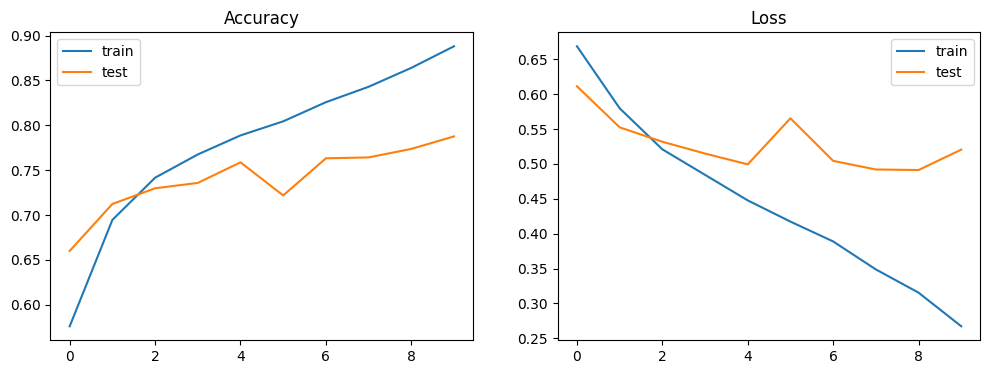

In [12]:
# Cell 7: Danh gia + ve bieu do accuracy/loss
loss, acc = model.evaluate(X_test, y_test_oh)
print("Do chinh xac tren tap test:", round(acc * 100, 2), "%")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Loss'); plt.legend()
plt.show()

# Cell 8: Thu du doan 1 anh trong tap test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


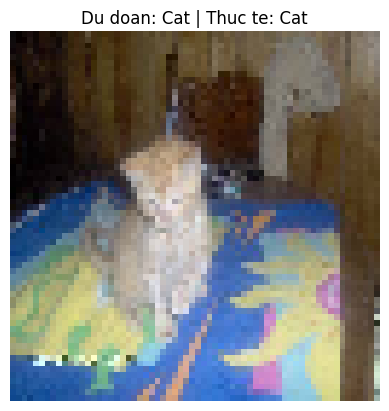

In [16]:
# Cell 8: Thu du doan 1 anh trong tap test
labels_name = ['Cat', 'Dog']

idx = random.randint(0, len(X_test)-1)  
sample = X_test[idx]
pred = model.predict(sample.reshape(1, 64, 64, 3))
pred_label = labels_name[np.argmax(pred)]
true_label = labels_name[np.argmax(y_test_oh[idx])]

plt.imshow(sample)
plt.title("Du doan: " + pred_label + " | Thuc te: " + true_label)
plt.axis('off')
plt.show()